In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.models import Model

# **Load MNIST Dataset**

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

#Normalize
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255


#Reshape
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# **Add Noise**

In [3]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor*np.random.normal(size=x_train.shape)

x_test_noisy = x_test + noise_factor*np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

# **Display Noisy Image**

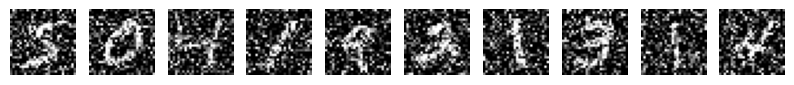

In [4]:
plt.figure(figsize=(10,2))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.show()

# **Build AutoEncoder**

In [5]:
#Encoder
input_img = Input(shape=(28,28,1))

x = Conv2D(32,(3,3),activation='relu',padding='same')(input_img)

x = MaxPooling2D((2,2),padding='same')(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)

encoded = MaxPooling2D((2,2),padding='same')(x)

#Decoder
x = Conv2D(32,(3,3),activation='relu',padding='same')(encoded)

x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)

x = UpSampling2D((2,2))(x)

decoded = Conv2D(1,(3,3),activation='sigmoid',padding='same')(x)

#Model
autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# **Train the Model**

In [6]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy,x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 152s 320ms/step - loss: 0.1715 - val_loss: 0.1187
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 190s 294ms/step - loss: 0.1159 - val_loss: 0.1102
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 147s 313ms/step - loss: 0.1097 - val_loss: 0.1062
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 146s 312ms/step - loss: 0.1063 - val_loss: 0.1041
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 193s 292ms/step - loss: 0.1042 - val_loss: 0.1020
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 132s 281ms/step - loss: 0.1026 - val_loss: 0.1010
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 286ms/step - loss: 0.1014 - val_loss: 0.0999
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 283ms/step - loss: 0.1005 - val_loss: 0.0993
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 131s 279ms/step - loss: 0.0997 - val_loss: 0.0987
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 280ms/step - loss: 0.0991 - val_loss: 0.0980


# **Predict**

In [7]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step


# **Display Result**

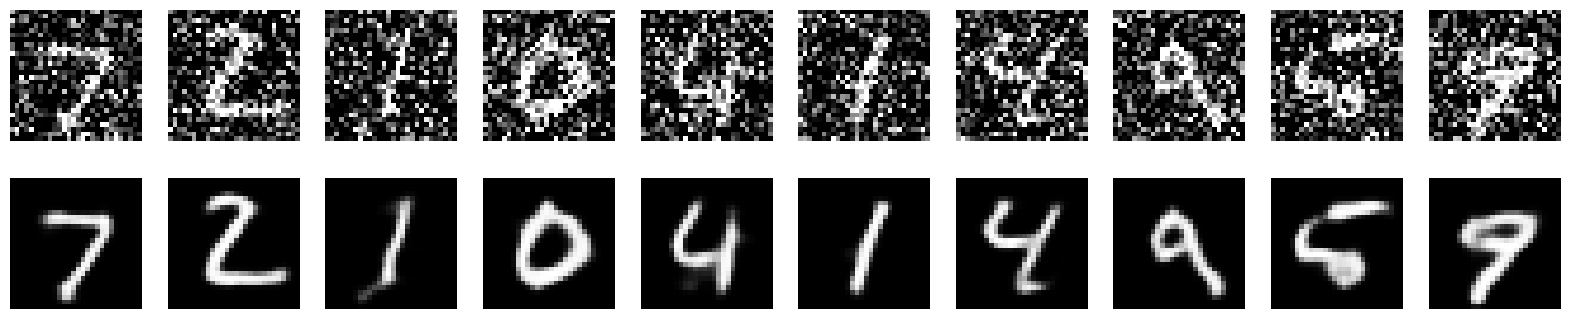

In [8]:
n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # Noisy image
    ax = plt.subplot(2,n,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Reconstructed image
    ax = plt.subplot(2,n,i+n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

# **Loss Graph**

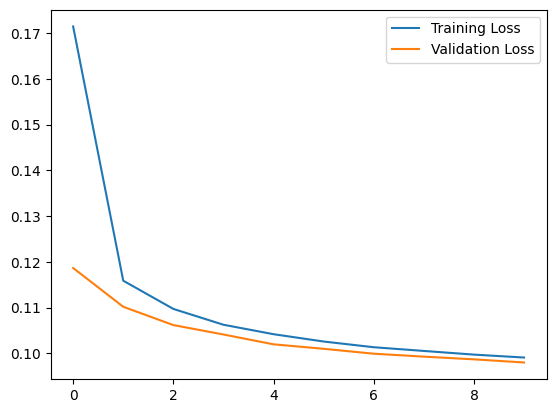

In [9]:
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.legend()
plt.show()

The training and validation loss decreased consistently throughout the training process, indicating that the denoising autoencoder successfully learned to reconstruct clean images from noisy inputs. The validation loss remained slightly lower than the training loss, suggesting good generalization without signs of overfitting. The close proximity of both curves indicates stable training and effective model performance.